In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore
import numpy as np

In [3]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [5]:
df.shape

(4269, 13)

In [6]:
print(df.head())
print(df.tail())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [7]:
# encoding and decoding
categorical_col = [' education', ' self_employed',  ' loan_status']
df_encoded = pd.get_dummies(df, columns=categorical_col, drop_first=True, dtype= int)
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded.head()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes,loan_status_ Rejected
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,1
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1,1


In [8]:
X = df_encoded.drop('loan_status_ Rejected' ,axis=1)
y = df_encoded['loan_status_ Rejected']

In [9]:
# Train Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (3415, 12)
Shape of X_test: (854, 12)
Shape of y_train: (3415,)
Shape of y_test: (854,)


In [11]:
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')


Accuracy: 0.9086651053864169
Confusion Matrix:
[[482  54]
 [ 24 294]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       536
           1       0.84      0.92      0.88       318

    accuracy                           0.91       854
   macro avg       0.90      0.91      0.90       854
weighted avg       0.91      0.91      0.91       854

Precision: 0.8448275862068966
Recall: 0.9245283018867925


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [14]:
# 1. Load data
df = pd.read_csv('/content/loan_approval_dataset.csv')

# 2. Drop missing values
df = df.dropna()

# 3. Encode categorical columns
categorical_cols = [' education', ' self_employed', ' loan_status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df_encoded.columns = df_encoded.columns.str.strip()

In [15]:
df_encoded.head()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes,loan_status_ Rejected
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,1
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1,1


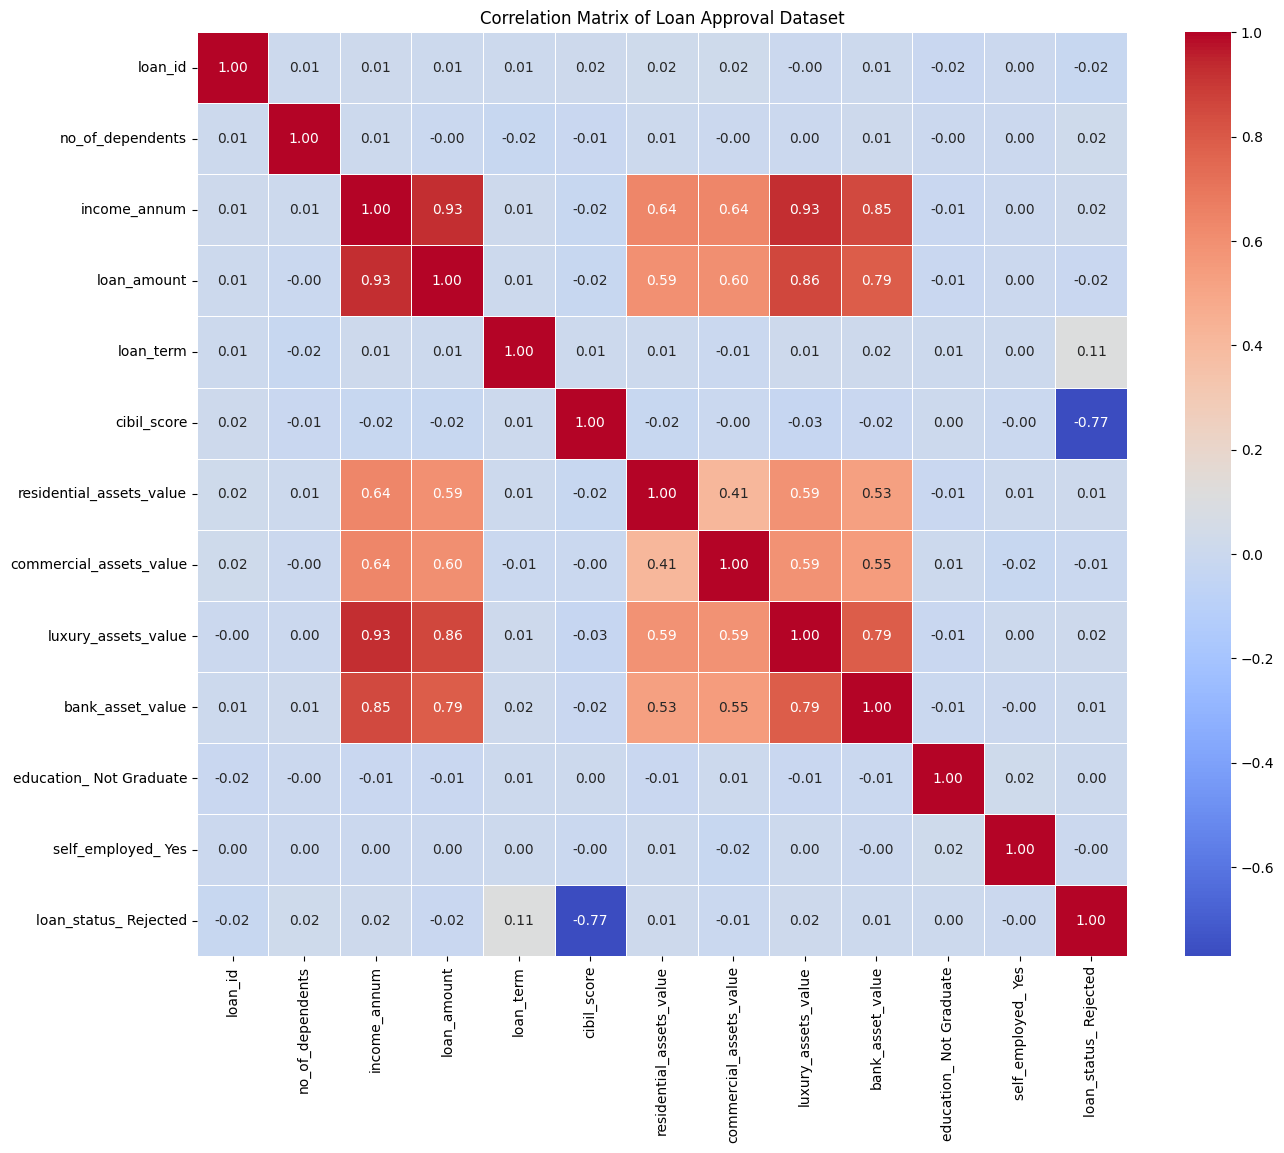

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Loan Approval Dataset')
plt.show()

In [17]:
# Get feature names from the original DataFrame X
feature_names = X.columns

# Get coefficients from the logistic regression model
# Since X_train was scaled, the coefficients reflect the importance of the scaled features
coefficients = lr.coef_[0]

# Create a DataFrame to easily view and sort feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Sort by absolute importance to find the most impactful features
feature_importance_df['Absolute_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("Top 10 Feature Importances (based on Logistic Regression coefficients):")
display(feature_importance_df.head(10))

Top 10 Feature Importances (based on Logistic Regression coefficients):


,Feature,Importance,Absolute_Importance
5,cibil_score,-4.291516,4.291516
2,income_annum,1.532873,1.532873
3,loan_amount,-1.166079,1.166079
4,loan_term,0.785140,0.785140
8,luxury_assets_value,-0.277322,0.277322
9,bank_asset_value,-0.127280,0.127280
7,commercial_assets_value,-0.082028,0.082028
0,loan_id,-0.074546,0.074546
11,self_employed_ Yes,-0.058735,0.058735
6,residential_assets_value,-0.041558,0.041558


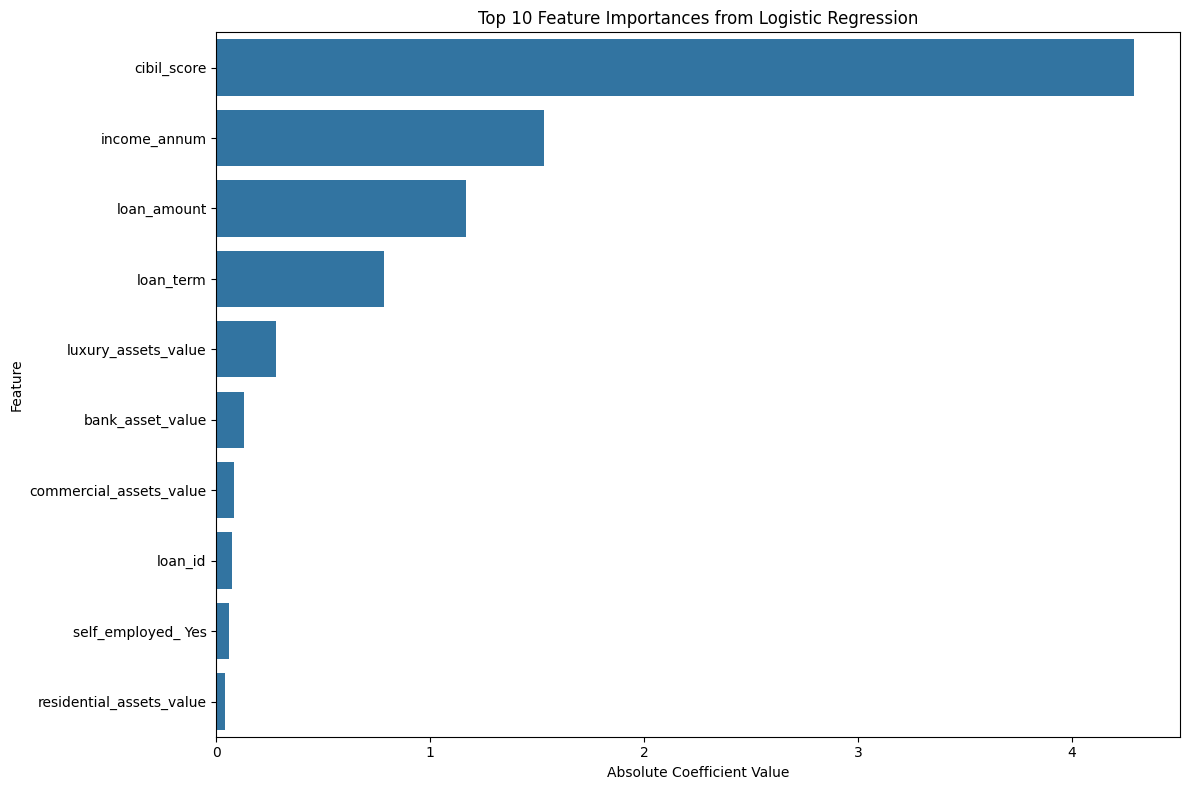

In [18]:
# Plotting feature importances
fig = plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances from Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Decision Tree Classifier

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_classifier.predict(X_test)
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

# Evaluate the Decision Tree Classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
confusion_dt = confusion_matrix(y_test, y_pred_dt)
classification_rep_dt = classification_report(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Calculate ROC-AUC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

print(f'Decision Tree Accuracy: {accuracy_dt}')
print(f'Decision Tree Confusion Matrix:\n{confusion_dt}')
print(f'Decision Tree Classification Report:\n{classification_rep_dt}')
print(f'Decision Tree Precision: {precision_dt}')
print(f'Decision Tree Recall: {recall_dt}')
print(f'Decision Tree F1-Score: {f1_dt}')
print(f'Decision Tree ROC-AUC: {roc_auc_dt}')

Decision Tree Accuracy: 0.9754098360655737
Decision Tree Confusion Matrix:
[[526  10]
 [ 11 307]]
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

Decision Tree Precision: 0.9684542586750788
Decision Tree Recall: 0.9654088050314465
Decision Tree F1-Score: 0.9669291338582677
Decision Tree ROC-AUC: 0.9733760443067679


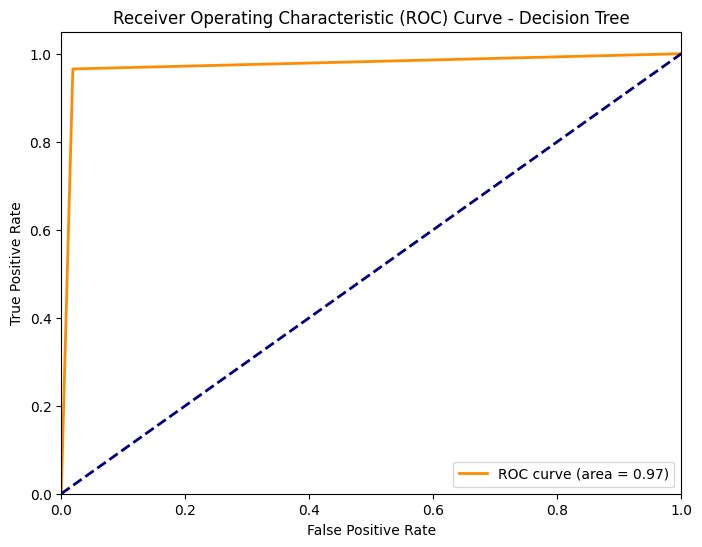

In [20]:
# Plot ROC Curve for Decision Tree
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()

## Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the Random Forest Classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
confusion_rf = confusion_matrix(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Calculate ROC-AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f'Random Forest Accuracy: {accuracy_rf}')
print(f'Random Forest Confusion Matrix:\n{confusion_rf}')
print(f'Random Forest Classification Report:\n{classification_rep_rf}')
print(f'Random Forest Precision: {precision_rf}')
print(f'Random Forest Recall: {recall_rf}')
print(f'Random Forest F1-Score: {f1_rf}')
print(f'Random Forest ROC-AUC: {roc_auc_rf}')

Random Forest Accuracy: 0.9789227166276346
Random Forest Confusion Matrix:
[[532   4]
 [ 14 304]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.99      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854

Random Forest Precision: 0.987012987012987
Random Forest Recall: 0.9559748427672956
Random Forest F1-Score: 0.9712460063897763
Random Forest ROC-AUC: 0.9978380503144655


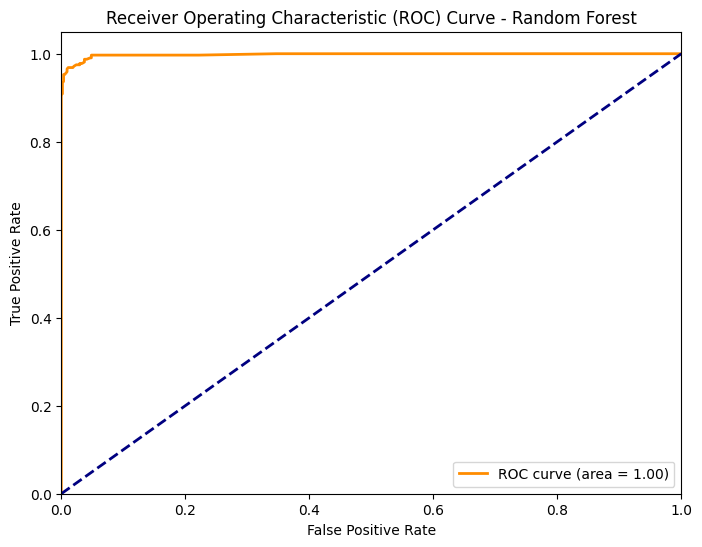

In [22]:
# Plot ROC Curve for Random Forest
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

## Hyperparameter Tuning for Random Forest Classifier

To further optimize the Random Forest Classifier, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination, and identifying the best performing set of parameters based on a specified scoring metric (in this case, ROC-AUC).

In [23]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30, None],  # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced']      # Ensure balanced class weight
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid,
                           scoring='roc_auc', cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

# Get the best estimator
best_rf_estimator = grid_search.best_estimator_

# Predict on the test set with the tuned model
y_pred_tuned_rf = best_rf_estimator.predict(X_test)
y_pred_proba_tuned_rf = best_rf_estimator.predict_proba(X_test)[:, 1]

# Evaluate the tuned Random Forest Classifier
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
confusion_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
classification_rep_tuned_rf = classification_report(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
fpr_tuned_rf, tpr_tuned_rf, thresholds_tuned_rf = roc_curve(y_test, y_pred_proba_tuned_rf)
roc_auc_tuned_rf = auc(fpr_tuned_rf, tpr_tuned_rf)

print(f'\nTuned Random Forest Accuracy: {accuracy_tuned_rf}')
print(f'Tuned Random Forest Confusion Matrix:\n{confusion_tuned_rf}')
print(f'Tuned Random Forest Classification Report:\n{classification_rep_tuned_rf}')
print(f'Tuned Random Forest Precision: {precision_tuned_rf}')
print(f'Tuned Random Forest Recall: {recall_tuned_rf}')
print(f'Tuned Random Forest F1-Score: {f1_tuned_rf}')
print(f'Tuned Random Forest ROC-AUC: {roc_auc_tuned_rf}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found by GridSearchCV:
{'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 2, 'n_estimators': 200}

Tuned Random Forest Accuracy: 0.9789227166276346
Tuned Random Forest Confusion Matrix:
[[527   9]
 [  9 309]]
Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Tuned Random Forest Precision: 0.9716981132075472
Tuned Random Forest Recall: 0.9716981132075472
Tuned Random Forest F1-Score: 0.9716981132075472
Tuned Random Forest ROC-AUC: 0.9978175161926218


## XGBoost Classifier

In [24]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost Classifier
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
confusion_xgb = confusion_matrix(y_test, y_pred_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Calculate ROC-AUC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

print(f'XGBoost Accuracy: {accuracy_xgb}')
print(f'XGBoost Confusion Matrix:\n{confusion_xgb}')
print(f'XGBoost Classification Report:\n{classification_rep_xgb}')
print(f'XGBoost Precision: {precision_xgb}')
print(f'XGBoost Recall: {recall_xgb}')
print(f'XGBoost F1-Score: {f1_xgb}')
print(f'XGBoost ROC-AUC: {roc_auc_xgb}')

XGBoost Accuracy: 0.977751756440281
XGBoost Confusion Matrix:
[[528   8]
 [ 11 307]]
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

XGBoost Precision: 0.9746031746031746
XGBoost Recall: 0.9654088050314465
XGBoost F1-Score: 0.9699842022116903
XGBoost ROC-AUC: 0.9977001783535153


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [05:31:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


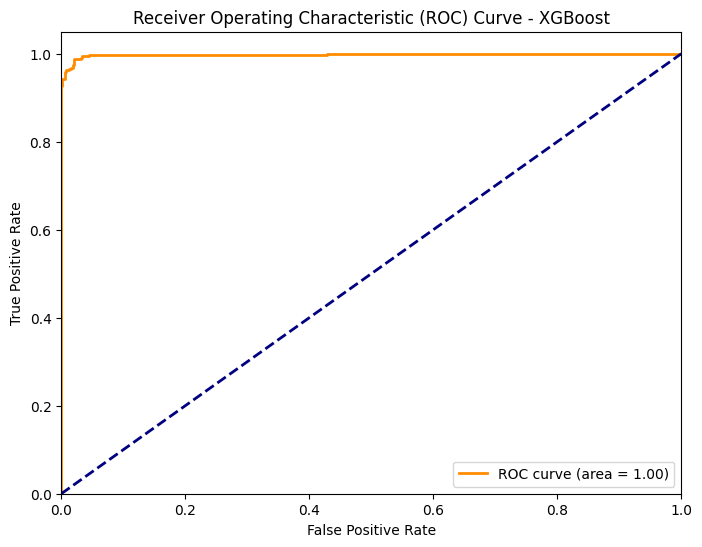

In [25]:
# Plot ROC Curve for XGBoost
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

In [26]:
print(df_encoded.columns.tolist())

['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_ Not Graduate', 'self_employed_ Yes', 'loan_status_ Rejected']


## Project Structure Setup

This section will create the necessary directories and placeholder files for the `loan-risk-prediction` project structure as requested. The current notebook is assumed to be `EDA_and_Model_Training.ipynb` and will not be recreated. We will copy the raw dataset into the `data` directory and create empty placeholder files for models, backend, frontend, and utility scripts.

In [27]:
import os
import shutil

project_root = 'loan-risk-prediction'

# Create main project directory if it doesn't exist
if not os.path.exists(project_root):
    os.makedirs(project_root)
    print(f"Created directory: {project_root}")

# Define subdirectories
subdirectories = [
    'data',
    'notebooks',
    'models',
    'backend',
    'frontend',
    'utils'
]

# Create subdirectories
for subdir in subdirectories:
    path = os.path.join(project_root, subdir)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created directory: {path}")

# Copy the dataset to the data directory
source_csv = '/content/loan_approval_dataset.csv'
dest_csv = os.path.join(project_root, 'data', 'loan_dataset.csv')

if os.path.exists(source_csv) and not os.path.exists(dest_csv):
    shutil.copy(source_csv, dest_csv)
    print(f"Copied {source_csv} to {dest_csv}")
elif os.path.exists(dest_csv):
    print(f"Dataset already exists at {dest_csv}")
else:
    print(f"Source CSV {source_csv} not found.")

print("Directory structure and dataset setup complete.")

Created directory: loan-risk-prediction/data
Created directory: loan-risk-prediction/models
Created directory: loan-risk-prediction/backend
Created directory: loan-risk-prediction/frontend
Created directory: loan-risk-prediction/utils
Copied /content/loan_approval_dataset.csv to loan-risk-prediction/data/loan_dataset.csv
Directory structure and dataset setup complete.


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
# Create placeholder files

file_paths = [
    os.path.join(project_root, 'models', 'loan_model.pkl'),
    os.path.join(project_root, 'models', 'scaler.pkl'),
    os.path.join(project_root, 'models', 'encoder.pkl'),
    os.path.join(project_root, 'models', 'feature_columns.pkl'),
    os.path.join(project_root, 'backend', 'app.py'),
    os.path.join(project_root, 'backend', 'predictor.py'),
    os.path.join(project_root, 'backend', 'preprocessing.py'),
    os.path.join(project_root, 'frontend', 'streamlit_app.py'),
    os.path.join(project_root, 'utils', 'validation.py'),
    os.path.join(project_root, 'utils', 'visualization.py'),
    os.path.join(project_root, 'requirements.txt'),
    os.path.join(project_root, 'README.md'),
    os.path.join(project_root, '.gitignore')
]

for file_path in file_paths:
    if not os.path.exists(file_path):
        with open(file_path, 'w') as f:
            # Add basic content for specific files
            if 'requirements.txt' in file_path:
                f.write('pandas\n')
                f.write('numpy\n')
                f.write('scikit-learn\n')
                f.write('joblib\n')
                f.write('matplotlib\n')
                f.write('seaborn\n')
                f.write('streamlit\n')
                f.write('fastapi\n')
                f.write('uvicorn\n')
                f.write('xgboost\n')
                f.write('imblearn\n')
            elif 'README.md' in file_path:
                f.write('# Intelligent Loan Approval & Credit Risk Prediction System\n\nThis project aims to develop a full-stack machine learning application that predicts loan approval status and provides risk analysis.\n')
            elif '.gitignore' in file_path:
                f.write('__pycache__/\n')
                f.write('*.pyc\n')
                f.write('*.pkl\n')
                f.write('.env\n')
                f.write('.ipynb_checkpoints/\n')
                f.write('models/*.pkl\n')
            else:
                f.write(f'# Placeholder for {os.path.basename(file_path)}\n')
        print(f"Created placeholder file: {file_path}")
    else:
        print(f"File already exists: {file_path}")

print("Placeholder files created.")

Created placeholder file: loan-risk-prediction/models/loan_model.pkl
Created placeholder file: loan-risk-prediction/models/scaler.pkl
Created placeholder file: loan-risk-prediction/models/encoder.pkl
Created placeholder file: loan-risk-prediction/models/feature_columns.pkl
Created placeholder file: loan-risk-prediction/backend/app.py
Created placeholder file: loan-risk-prediction/backend/predictor.py
Created placeholder file: loan-risk-prediction/backend/preprocessing.py
Created placeholder file: loan-risk-prediction/frontend/streamlit_app.py
Created placeholder file: loan-risk-prediction/utils/validation.py
Created placeholder file: loan-risk-prediction/utils/visualization.py
Created placeholder file: loan-risk-prediction/requirements.txt
Created placeholder file: loan-risk-prediction/README.md
Created placeholder file: loan-risk-prediction/.gitignore
Placeholder files created.


In [30]:
import joblib
import os

# Save the best Random Forest model
joblib.dump(best_rf_estimator, os.path.join(project_root, 'models', 'loan_model.pkl'))
print("Saved loan_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, os.path.join(project_root, 'models', 'scaler.pkl'))
print("Saved scaler.pkl")

# Save the feature columns to ensure consistent order during prediction
joblib.dump(X.columns.tolist(), os.path.join(project_root, 'models', 'feature_columns.pkl'))
print("Saved feature_columns.pkl")

Saved loan_model.pkl
Saved scaler.pkl
Saved feature_columns.pkl


Now, let's create the `preprocessing.py` file.

In [31]:
%%writefile loan-risk-prediction/backend/preprocessing.py
import pandas as pd
import joblib

def preprocess_data(df: pd.DataFrame, is_train: bool = True, scaler=None, feature_columns=None):
    """
    Preprocesses the raw input data.
    Args:
        df (pd.DataFrame): The input DataFrame.
        is_train (bool): True if processing training data, False otherwise.
        scaler: Fitted StandardScaler object (required for test data).
        feature_columns: List of feature columns (required for test data).
    Returns:
        pd.DataFrame: Preprocessed DataFrame.
        StandardScaler: Fitted StandardScaler object if is_train is True.
    """

    # Ensure column names are stripped of leading/trailing spaces
    df.columns = df.columns.str.strip()

    # Handle categorical features using one-hot encoding
    categorical_cols = ['education', 'self_employed'] # 'loan_status' is target
    # Ensure all categorical columns exist before applying get_dummies
    for col in categorical_cols:
        if col not in df.columns:
            df[col] = 'Unknown' # Or handle with a more appropriate default/error

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    df_encoded.columns = df_encoded.columns.str.strip()

    if is_train:
        # For training data, we want to separate features and target
        if 'loan_status_Rejected' in df_encoded.columns:
            X = df_encoded.drop('loan_status_Rejected', axis=1)
            y = df_encoded['loan_status_Rejected']
        else:
            # If 'loan_status_Rejected' is not present, assume it's for prediction
            X = df_encoded
            y = None

        # Fit and transform the scaler on training features
        scaler = joblib.load('loan-risk-prediction/models/scaler.pkl') # Load existing scaler for consistency
        X_scaled = scaler.fit_transform(X)
        X_processed = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

        # Save feature columns for consistency in prediction
        joblib.dump(X.columns.tolist(), 'loan-risk-prediction/models/feature_columns.pkl')

        return X_processed, y, scaler, X.columns.tolist()
    else:
        # For prediction data, use provided scaler and feature columns
        if scaler is None or feature_columns is None:
            raise ValueError("Scaler and feature_columns must be provided for prediction data.")

        # Align columns with training data features, filling missing with 0
        X_processed = df_encoded.reindex(columns=feature_columns, fill_value=0)

        # Transform using the fitted scaler
        X_scaled = scaler.transform(X_processed)
        X_processed = pd.DataFrame(X_scaled, columns=feature_columns, index=X_processed.index)

        return X_processed


Overwriting loan-risk-prediction/backend/preprocessing.py


Next, let's create the `predictor.py` file.

In [32]:
%%writefile loan-risk-prediction/backend/predictor.py
import joblib
import pandas as pd
from backend.preprocessing import preprocess_data # Assuming preprocessing.py is in the same directory

class LoanPredictor:
    def __init__(self, model_path='loan-risk-prediction/models/loan_model.pkl',
                 scaler_path='loan-risk-prediction/models/scaler.pkl',
                 feature_columns_path='loan-risk-prediction/models/feature_columns.pkl'):
        self.model = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path)
        self.feature_columns = joblib.load(feature_columns_path)

    def predict(self, raw_data: dict) -> dict:
        # Convert raw input data (e.g., from an API request) to a pandas DataFrame
        input_df = pd.DataFrame([raw_data])

        # Preprocess the input data using the trained scaler and feature columns
        processed_df = preprocess_data(input_df, is_train=False,
                                       scaler=self.scaler,
                                       feature_columns=self.feature_columns)

        # Make prediction
        prediction = self.model.predict(processed_df)
        prediction_proba = self.model.predict_proba(processed_df)

        # Convert prediction to 'Approved' or 'Rejected'
        loan_status = 'Rejected' if prediction[0] == 1 else 'Approved'

        # Return results
        return {
            'loan_status': loan_status,
            'probability_rejected': float(prediction_proba[0][1]),
            'probability_approved': float(prediction_proba[0][0])
        }

    def predict_batch(self, raw_data_list: list) -> list:
        # Convert list of raw input data to a pandas DataFrame
        input_df = pd.DataFrame(raw_data_list)

        # Preprocess the input data
        processed_df = preprocess_data(input_df, is_train=False,
                                       scaler=self.scaler,
                                       feature_columns=self.feature_columns)

        # Make batch predictions
        predictions = self.model.predict(processed_df)
        prediction_probas = self.model.predict_proba(processed_df)

        results = []
        for i in range(len(predictions)):
            loan_status = 'Rejected' if predictions[i] == 1 else 'Approved'
            results.append({
                'loan_status': loan_status,
                'probability_rejected': float(prediction_probas[i][1]),
                'probability_approved': float(prediction_probas[i][0])
            })
        return results


Overwriting loan-risk-prediction/backend/predictor.py


In [33]:
%%writefile loan-risk-prediction/README.md
# Intelligent Loan Approval & Credit Risk Prediction System

## Project Overview
This project develops a full-stack machine learning application for predicting loan approval status and providing credit risk analysis. It leverages historical loan data to train robust classification models, which are then deployed as a backend API for real-time predictions and a Streamlit frontend for interactive user experience.

## Project Structure
```
loan-risk-prediction/
├── data/                         # Stores the raw and processed datasets
│   └── loan_dataset.csv
├── notebooks/                    # Jupyter notebooks for EDA, model training, and evaluation
│   └── EDA_and_Model_Training.ipynb
├── models/                       # Stores trained machine learning models and related artifacts
│   ├── loan_model.pkl
│   ├── scaler.pkl
│   └── feature_columns.pkl
├── backend/                      # FastAPI backend for model inference
│   ├── app.py
│   ├── predictor.py
│   └── preprocessing.py
├── frontend/                     # Streamlit frontend for user interaction
│   └── streamlit_app.py
├── utils/                        # Utility scripts (e.g., data validation, visualization)
│   ├── validation.py
│   └── visualization.py
├── requirements.txt              # Python dependencies
├── README.md                     # Project documentation
└── .gitignore                    # Specifies intentionally untracked files to ignore
```

## Features
- **Data Preprocessing**: Handles categorical encoding, feature scaling, and missing value imputation.
- **Model Training**: Explores Logistic Regression, Decision Tree, Random Forest, and XGBoost classifiers.
- **Hyperparameter Tuning**: Utilizes GridSearchCV to optimize Random Forest for best performance.
- **Model Deployment**: Exposes the trained model via a FastAPI backend for real-time predictions.
- **Interactive Frontend**: Provides a user-friendly Streamlit interface for inputting loan application details and receiving instant predictions.
- **Performance Evaluation**: Includes metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC for model assessment.

## Data Source
The project uses the `loan_approval_dataset.csv`, which contains various attributes related to loan applicants and their approval status. Key features include income, loan amount, CIBIL score, and asset values.

## Models Used
- **Logistic Regression**: A linear model for binary classification.
- **Decision Tree Classifier**: A non-linear model that partitions data based on features.
- **Random Forest Classifier**: An ensemble method using multiple decision trees, known for its robustness and accuracy.
- **XGBoost Classifier**: An optimized distributed gradient boosting library designed to be highly efficient, flexible and portable.

## Setup and Installation

### Prerequisites
- Python 3.8+
- pip

### Installation Steps
1.  **Clone the repository (if applicable)**:
    ```bash
    git clone <repository-url>
    cd loan-risk-prediction
    ```

2.  **Install dependencies**:
    ```bash
    pip install -r requirements.txt
    ```

3.  **Ensure data and models are in place**:
    - The `loan_dataset.csv` should be in the `data/` directory.
    - Trained models (`loan_model.pkl`, `scaler.pkl`, `feature_columns.pkl`) should be in the `models/` directory. These are generated by running the `EDA_and_Model_Training.ipynb` notebook.

## Running the Application

### Backend API (FastAPI)
To start the backend API, navigate to the `backend` directory and run:
```bash
cd backend
uvicorn app:app --reload
```
The API will be accessible at `http://127.0.0.1:8000` (or `http://0.0.0.0:8000` if running in a container).

### Frontend (Streamlit)
To run the Streamlit application, navigate to the `frontend` directory and execute:
```bash
cd frontend
streamlit run streamlit_app.py
```
The Streamlit app will open in your web browser, typically at `http://localhost:8501`.

## Usage
- **Interactive Predictions**: Use the Streamlit interface to input new loan application data and get instant approval predictions.
- **API Integration**: Integrate with the FastAPI backend from other applications to programmatically get loan approval predictions.

## Future Enhancements
- Implement more advanced data imputation techniques.
- Explore other machine learning models (e.g., Neural Networks).
- Develop MLOps pipelines for continuous integration and deployment.
- Add user authentication and authorization.
- Improve UI/UX of the Streamlit application.

## Contact
For any questions or suggestions, please contact [Your Name/Email/GitHub Profile].


Overwriting loan-risk-prediction/README.md


In [34]:
%%writefile loan-risk-prediction/frontend/streamlit_app.py
import streamlit as st
import pandas as pd
import requests # To make requests to our FastAPI backend
import json

# --- Page Configuration ---
st.set_page_config(page_title='Loan Approval Predictor', page_icon=':bank:', layout='wide')

# --- Header ---
st.title('🏛️ Intelligent Loan Approval & Credit Risk Prediction System')
st.markdown("Welcome to the Loan Approval Predictor. Please enter the applicant's details below to get an instant loan approval prediction.")

# --- FastAPI Endpoint ---
FASTAPI_URL = "http://127.0.0.1:8000/predict/" # Adjust if your FastAPI runs on a different host/port

# --- Input Form ---
st.header('Applicant Information')

with st.form("loan_application_form"):
    col1, col2 = st.columns(2)

    with col1:
        income_annum = st.number_input('Annual Income (in INR)', min_value=100000, max_value=100000000, value=5000000, step=100000)
        loan_amount = st.number_input('Loan Amount (in INR)', min_value=100000, max_value=50000000, value=15000000, step=100000)
        loan_term = st.selectbox('Loan Term (in years)', options=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20], index=4) # Default to 10 years
        cibil_score = st.number_input('CIBIL Score', min_value=300, max_value=900, value=750, step=1)
        no_of_dependents = st.slider('Number of Dependents', min_value=0, max_value=5, value=2)
        education = st.selectbox('Education', options=['Graduate', 'Not Graduate'])

    with col2:
        residential_assets_value = st.number_input('Residential Assets Value (in INR)', min_value=0, max_value=100000000, value=5000000, step=100000)
        commercial_assets_value = st.number_input('Commercial Assets Value (in INR)', min_value=0, max_value=100000000, value=2000000, step=100000)
        luxury_assets_value = st.number_input('Luxury Assets Value (in INR)', min_value=0, max_value=100000000, value=10000000, step=100000)
        bank_asset_value = st.number_input('Bank Asset Value (in INR)', min_value=0, max_value=100000000, value=3000000, step=100000)
        self_employed = st.selectbox('Self Employed', options=['Yes', 'No'])

    submitted = st.form_submit_button("Get Loan Prediction")

    if submitted:
        # Prepare data for FastAPI
        input_data = {
            'loan_id': 0, # Placeholder, not used in prediction logic directly but needed for schema
            'no_of_dependents': no_of_dependents,
            'education': education,
            'self_employed': self_employed,
            'income_annum': income_annum,
            'loan_amount': loan_amount,
            'loan_term': loan_term,
            'cibil_score': cibil_score,
            'residential_assets_value': residential_assets_value,
            'commercial_assets_value': commercial_assets_value,
            'luxury_assets_value': luxury_assets_value,
            'bank_asset_value': bank_asset_value,
            'loan_status': 'Unknown' # Placeholder, will be predicted
        }

        try:
            response = requests.post(FASTAPI_URL, json=input_data)
            response.raise_for_status() # Raise an exception for HTTP errors
            prediction_result = response.json()

            st.subheader('Prediction Result:')
            if prediction_result['loan_status'] == 'Approved':
                st.success(f"**Loan Status: {prediction_result['loan_status']}**")
                st.balloons()
            else:
                st.error(f"**Loan Status: {prediction_result['loan_status']}**")

            st.write(f"Probability of Approval: {prediction_result['probability_approved']:.2f}")
            st.write(f"Probability of Rejection: {prediction_result['probability_rejected']:.2f}")

            st.markdown("--- Request Details ---")
            st.json(input_data)
            st.markdown("--- Response Details ---")
            st.json(prediction_result)

        except requests.exceptions.ConnectionError:
            st.error(f"Could not connect to FastAPI backend at {FASTAPI_URL}. Please ensure the backend server is running.")
        except requests.exceptions.HTTPError as e:
            st.error(f"HTTP error occurred: {e}. Response: {response.text}")
        except json.JSONDecodeError:
            st.error(f"Failed to decode JSON response from API. Response text: {response.text}")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")



Overwriting loan-risk-prediction/frontend/streamlit_app.py


Now, let's fill the `app.py` file for the FastAPI backend.

In [35]:
%%writefile loan-risk-prediction/backend/app.py
from fastapi import FastAPI
from pydantic import BaseModel
from backend.predictor import LoanPredictor

# Initialize FastAPI app
app = FastAPI(
    title="Loan Approval Prediction API",
    description="API for predicting loan approval status based on applicant data.",
    version="1.0.0",
)

# Initialize the predictor globally to load the model only once
predictor = LoanPredictor()

# Define Request Body Model
class LoanApplication(BaseModel):
    loan_id: int
    no_of_dependents: int
    education: str
    self_employed: str
    income_annum: int
    loan_amount: int
    loan_term: int
    cibil_score: int
    residential_assets_value: int
    commercial_assets_value: int
    luxury_assets_value: int
    bank_asset_value: int
    loan_status: str # This will be ignored for prediction, but kept for schema consistency

# Define Batch Request Body Model
class LoanApplicationBatch(BaseModel):
    applications: list[LoanApplication]

# --- API Endpoints ---

@app.get("/", summary="Health Check")
async def read_root():
    return {"message": "Loan Approval Prediction API is running!"}

@app.post("/predict/", response_model=dict, summary="Predict Loan Approval for a single application")
async def predict_loan_status(application: LoanApplication):
    """
    Predicts the loan approval status for a single applicant.

    - **loan_id**: Unique identifier for the loan (integer)
    - **no_of_dependents**: Number of dependents (integer)
    - **education**: Education level (string: 'Graduate', 'Not Graduate')
    - **self_employed**: Self-employed status (string: 'Yes', 'No')
    - **income_annum**: Annual income in INR (integer)
    - **loan_amount**: Requested loan amount in INR (integer)
    - **loan_term**: Loan term in years (integer)
    - **cibil_score**: CIBIL score (integer)
    - **residential_assets_value**: Value of residential assets in INR (integer)
    - **commercial_assets_value**: Value of commercial assets in INR (integer)
    - **luxury_assets_value**: Value of luxury assets in INR (integer)
    - **bank_asset_value**: Value of bank assets in INR (integer)
    - **loan_status**: Placeholder, expected 'Unknown' (string)

    Returns the predicted loan status and probabilities.
    """
    # Convert Pydantic model to dict for the predictor
    raw_data = application.dict()
    prediction_result = predictor.predict(raw_data)
    return prediction_result

@app.post("/predict_batch/", response_model=list[dict], summary="Predict Loan Approval for multiple applications")
async def predict_loan_status_batch(batch_applications: LoanApplicationBatch):
    """
    Predicts the loan approval status for a list of applicants.

    Accepts a list of `LoanApplication` objects and returns a list of prediction results.
    """
    raw_data_list = [app.dict() for app in batch_applications.applications]
    prediction_results = predictor.predict_batch(raw_data_list)
    return prediction_results


Overwriting loan-risk-prediction/backend/app.py


Now, let's fill the `validation.py` file.

In [36]:
%%writefile loan-risk-prediction/utils/validation.py
import pandas as pd

def validate_loan_data(df: pd.DataFrame) -> (bool, str):
    """
    Validates the input DataFrame for loan application data.
    Checks for expected columns and data types.
    """
    expected_columns = [
        'loan_id', 'no_of_dependents', 'education', 'self_employed',
        'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
        'residential_assets_value', 'commercial_assets_value',
        'luxury_assets_value', 'bank_asset_value', 'loan_status'
    ]

    # Check for missing columns
    missing_columns = [col for col in expected_columns if col not in df.columns]
    if missing_columns:
        return False, f"Missing columns: {', '.join(missing_columns)}"

    # Check data types (simplified for this example, adjust as needed)
    # Example: all numeric columns should be int or float
    numeric_cols = [
        'loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
        'loan_term', 'cibil_score', 'residential_assets_value',
        'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'
    ]
    for col in numeric_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            return False, f"Column '{col}' has incorrect data type. Expected numeric."

    # Check categorical values
    if not all(df['education'].isin(['Graduate', 'Not Graduate'])):
        return False, "Invalid values in 'education' column. Expected 'Graduate' or 'Not Graduate'."
    if not all(df['self_employed'].isin(['Yes', 'No'])):
        return False, "Invalid values in 'self_employed' column. Expected 'Yes' or 'No'."
    # loan_status can contain 'Approved', 'Rejected', or 'Unknown' for prediction input
    if not all(df['loan_status'].isin(['Approved', 'Rejected', 'Unknown'])):
        return False, "Invalid values in 'loan_status' column. Expected 'Approved', 'Rejected', or 'Unknown'."

    # Add more validation rules as necessary (e.g., range checks, cibil score min/max)

    return True, "Validation successful."


Overwriting loan-risk-prediction/utils/validation.py


Finally, let's fill the `visualization.py` file.

In [37]:
%%writefile loan-risk-prediction/utils/visualization.py
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_correlation_matrix(df: pd.DataFrame, title: str = 'Correlation Matrix') -> None:
    """
    Plots a heatmap of the correlation matrix for the given DataFrame.
    """
    plt.figure(figsize=(12, 10))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title(title)
    plt.show()

def plot_feature_importance(feature_names: list, importances: list, title: str = 'Feature Importance') -> None:
    """
    Plots a bar chart of feature importances.
    """
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(title)
    plt.xlabel('Importance Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, title='Receiver Operating Characteristic (ROC) Curve') -> None:
    """
    Plots the ROC curve.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

def plot_confusion_matrix(confusion_matrix_array, labels=['Approved', 'Rejected'], title='Confusion Matrix') -> None:
    """
    Plots a confusion matrix heatmap.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix_array, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()


Overwriting loan-risk-prediction/utils/visualization.py


In [38]:
import os
import shutil

# Get the path of the current notebook
# In Colab, the current notebook is typically in /content/
# We'll assume the notebook is named 'EDA_and_Model_Training.ipynb'
# If you save the notebook with a different name, please update this variable.
current_notebook_name = 'EDA_and_Model_Training.ipynb'
current_notebook_path = f'/content/{current_notebook_name}'

# Define the destination path within the project structure
project_root = 'loan-risk-prediction'
destination_dir = os.path.join(project_root, 'notebooks')
destination_path = os.path.join(destination_dir, current_notebook_name)

# Ensure the destination directory exists (it should have been created already)
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)

# Move the notebook
if os.path.exists(current_notebook_path):
    shutil.move(current_notebook_path, destination_path)
    print(f"Moved '{current_notebook_name}' to '{destination_path}'")
else:
    print(f"Error: '{current_notebook_name}' not found at '{current_notebook_path}'")
    print("Please make sure the notebook is saved and its name matches 'current_notebook_name'.")

Error: 'EDA_and_Model_Training.ipynb' not found at '/content/EDA_and_Model_Training.ipynb'
Please make sure the notebook is saved and its name matches 'current_notebook_name'.


### Accessing the `EDA_and_Model_Training.ipynb` file

The current notebook has been moved to the `loan-risk-prediction/notebooks/` directory.

To access it, you can download the entire `loan-risk-prediction` directory from the file browser on the left sidebar of Colab. This will include the `EDA_and_Model_Training.ipynb` file, along with all the other project files that were created.

In [39]:
!pip install pyngrok

In [40]:
!ngrok config add-authtoken YOUR_AUTHTOKEN_HERE

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [41]:
from pyngrok import ngrok
import uvicorn
import threading

# Start ngrok tunnel
public_url = ngrok.connect(8000)
print("FastAPI Public URL:", public_url)

# Run FastAPI in background
def run_app():
    uvicorn.run("app:app", host="0.0.0.0", port=8000)

threading.Thread(target=run_app).start()


ERROR:pyngrok.process.ngrok:t=2026-09-22T05:31:58+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-09-22T05:31:58+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.